# V25_csi_acc · 实盘每日操作指引 Notebook

**主版本**：V25 = V7 35 池 + V24 风格 12 板块重命名 + 真·中证全指 000985 加速度 regime

**核心创新** vs V22：
1. 板块标签从 9 → 12 细化（科技拆 半导体芯片 / 通信光模块 / AI数字 等）
2. Regime 信号从 "hs300_acc"（池均值）升级为真·中证全指 000985 加速度
3. top_k_groups 从 3 → 4（12 板块需要更广覆盖）

## 锁定参数

```python
mom_w=4, lam=1.5, top_n_a=4, vol_target=0.12
top_k_groups=4, per_group=1
risk_adj_nu=0.4, rev_w=0.05, accel_w=0.10, longmom_window=13
regime_accel_signal='csi_all_acc'   # ★ V25 真·中证全指
regime_accel_theta_on=0.05
regime_accel_theta_off=0.0
regime_accel_k_min=8
```

## 八维 vs V22

| 维度 | V22 | V25 | Δ |
|---|---:|---:|---:|
| Full Sharpe | 1.955 | **2.002** | +0.047 ✓ |
| Full 年化 | +25.12% | **+25.83%** | +0.71pp ✓ |
| Full 最大回撤 | -8.16% | -8.23% | -0.07pp ✗ |
| Full Calmar | 3.08 | **3.14** | +0.06 ✓ |
| OOS Sharpe | 2.097 | **2.189** | +0.092 ✓ |
| OOS 年化 | +29.79% | **+31.50%** | +1.71pp ✓ |
| OOS 最大回撤 | -6.00% | **-5.49%** | +0.51pp ✓ |
| OOS Calmar | 4.97 | **5.74** | +0.77 ✓ |

7 ✓ + 1 微败（Full DD 7bp）

In [1]:
# Cell 1: 环境与导入
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
rcParams['axes.unicode_minus'] = False

sys.path.insert(0, str(Path.cwd() / 'scripts'))
from _strategy_v15 import run_strategy, segment_stats, V7_ROOT

print('V25 实盘策略 notebook 启动')
print(f'数据来源: {V7_ROOT}')

V25 实盘策略 notebook 启动
数据来源: C:\Users\Hu\Downloads\Factor_Zoo-main\deploy\A-Share-ETF-Rotation-Strategy-2.0


In [2]:
# Cell 2: 锁定 V25 参数
CACHE = Path('data_cache')
V25_PARAMS = dict(
    mom_w=4, lam=1.5, top_n_a=4, vol_target=0.12,
    top_k_groups=4, per_group=1,
    risk_adj_nu=0.4, rev_w=0.05,
    accel_w=0.10, longmom_window=13,
    regime_accel_signal='csi_all_acc',
    regime_accel_theta_on=0.05, regime_accel_theta_off=0.0,
    regime_accel_k_min=8,
    uni_path=CACHE / 'etf_universe_v24diag.csv',
    csi_path=CACHE / 'csi_all_weekly.parquet',
)
print('V25 锁定参数:')
for k, v in V25_PARAMS.items():
    print(f'  {k} = {v}')

V25 锁定参数:
  mom_w = 4
  lam = 1.5
  top_n_a = 4
  vol_target = 0.12
  top_k_groups = 4
  per_group = 1
  risk_adj_nu = 0.4
  rev_w = 0.05
  accel_w = 0.1
  longmom_window = 13
  regime_accel_signal = csi_all_acc
  regime_accel_theta_on = 0.05
  regime_accel_theta_off = 0.0
  regime_accel_k_min = 8
  uni_path = data_cache\etf_universe_v24diag.csv
  csi_path = data_cache\csi_all_weekly.parquet


In [3]:
# Cell 3: 跑回测 + 三段式分段
result = run_strategy(**V25_PARAMS, return_full=True)
pnl_net = result['pnl_net']
w_final = result['w_final']
scale = result['scale']
gate_on = result['gate_on']
regime_log = result.get('regime_accel_log')
uni = result['uni']

ss = segment_stats(pnl_net)
print('=== V25 三段式分段指标 ===')
print(f"{'段':<10} {'周数':>5} {'年化':>10} {'波动':>8} {'Sharpe':>8} {'回撤':>8} {'Calmar':>8}")
for seg, lab in [('IS', 'IS 19-22'), ('Val', 'Val 23'), ('OOS', 'OOS 24+'), ('Full', 'Full')]:
    m = ss[seg]
    print(f'{lab:<10} {m["n"]:>5d} {m["ann"]*100:>+9.2f}% {m["vol"]*100:>7.2f}% {m["sharpe"]:>8.3f} '
          f'{m["mdd"]*100:>7.2f}% {m["calmar"]:>8.2f}')

=== V25 三段式分段指标 ===
段             周数         年化       波动   Sharpe       回撤   Calmar
IS 19-22     208    +23.56%   11.88%    1.984   -8.23%     2.86
Val 23        50    +22.20%   13.46%    1.649   -4.15%     5.35
OOS 24+      119    +31.50%   14.39%    2.189   -5.49%     5.74
Full         377    +25.83%   12.90%    2.002   -8.23%     3.14


In [4]:
# Cell 4: 当前 Regime 状态 + 下次调仓信息
latest = pnl_net.index[-1]
next_rebalance = latest + pd.Timedelta(days=4)
regime_now = bool(regime_log.iloc[-1]) if regime_log is not None else False
mode_now = 'RISK-ON' if bool(gate_on.iloc[-1]) else 'RISK-OFF (单仓黄金)'
scale_now = float(scale.iloc[-1])

print(f'=== 实时状态 ({latest.date()}) ===')
print(f'Gate Mode:        {mode_now}')
print(f'Regime CSI ON:   {"是 ★" if regime_now else "否（accel 因子关闭，退化为 V16）"}')
print(f'Vol target scale: {scale_now:.3f}  (越接近 1 = 满仓，越接近 0 = 缩仓)')
print(f'下次调仓日期:     {next_rebalance.date()} (周一开盘)')
print()
if regime_log is not None:
    on_pct = float(regime_log.mean())
    n_switches = int((regime_log != regime_log.shift(1)).sum())
    print(f'历史 Regime ON 占比: {on_pct*100:.1f}%')
    print(f'历史切换次数: {n_switches} 次')

=== 实时状态 (2026-04-23) ===
Gate Mode:        RISK-ON
Regime CSI ON:   是 ★
Vol target scale: 0.457  (越接近 1 = 满仓，越接近 0 = 缩仓)
下次调仓日期:     2026-04-27 (周一开盘)

历史 Regime ON 占比: 33.4%
历史切换次数: 24 次


In [5]:
# Cell 5: 当前持仓 + 下周操作建议
code2name = dict(zip(uni['ts_code'], uni['name']))
code2group = dict(zip(uni['ts_code'], uni['group']))
nz = w_final.iloc[-1]
nz = nz[nz > 1e-5].sort_values(ascending=False)

print(f'=== 下周持仓清单 ({next_rebalance.date()} 调仓) ===\n')
print(f"{'ts_code':<10} {'ETF 名称':<14} {'板块':<10} {'目标权重':>9}")
print('-' * 50)
for c, w in nz.items():
    print(f"{c:<10} {code2name.get(c, '?'):<14} {code2group.get(c, '?'):<10} {w*100:>8.2f}%")
print(f"{'合计':<35} {nz.sum()*100:>8.2f}%")
print(f"{'现金':<35} {(1-nz.sum())*100:>8.2f}%")

=== 下周持仓清单 (2026-04-27 调仓) ===

ts_code    ETF 名称         板块              目标权重
--------------------------------------------------
159779.SZ  消费电子ETF        AI数字          11.43%
589100.SH  科创芯片ETF        半导体芯片         11.43%
159890.SZ  云计算ETF         AI数字           5.71%
512660.SH  军工ETF          高端制造           5.71%
515880.SH  通信ETF          通信光模块          5.71%
515980.SH  AI_ETF         AI数字           5.71%
合计                                     45.71%
现金                                     54.29%


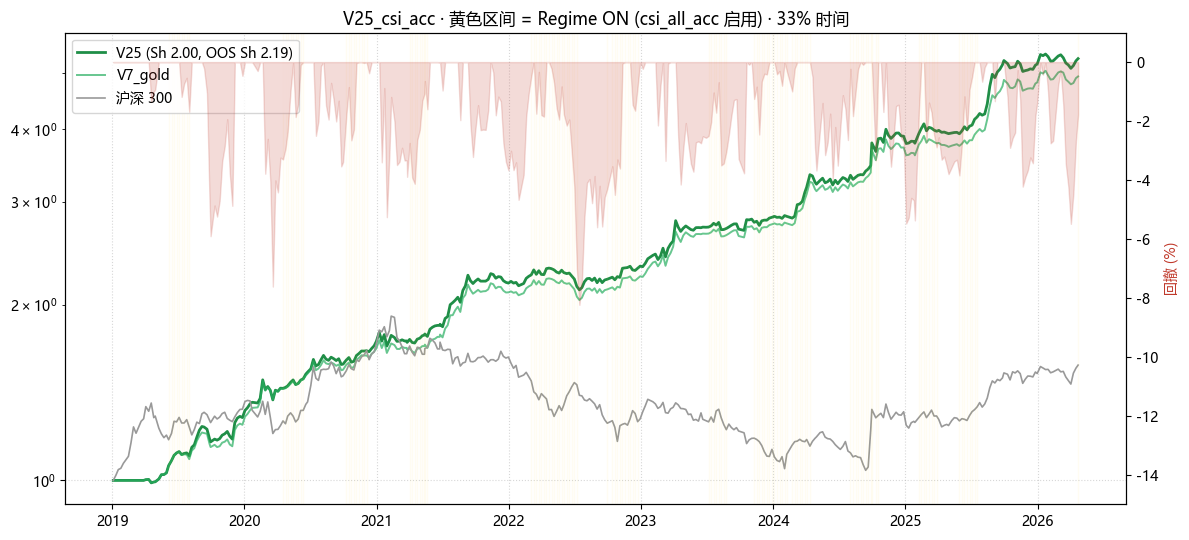

In [6]:
# Cell 6: NAV 曲线 + Regime 标记
nav = (1 + pnl_net.fillna(0)).cumprod()
hs = pd.read_csv(V7_ROOT / 'results' / 'nav_vs_benchmark.csv')
hs['trade_week'] = pd.to_datetime(hs['trade_week'])
bench = hs.set_index('trade_week')['nav_csi300'].reindex(nav.index, method='ffill')
bench = bench / bench.iloc[0]
v7_nav = hs.set_index('trade_week')['nav_v7_gold'].reindex(nav.index, method='ffill')

fig, ax = plt.subplots(figsize=(12, 5.5))
on_pct = float(regime_log.mean()) if regime_log is not None else 0.0
ax.plot(nav.index, nav.values, color='#1F8E47', lw=2.0,
        label=f'V25 (Sh {ss["Full"]["sharpe"]:.2f}, OOS Sh {ss["OOS"]["sharpe"]:.2f})')
ax.plot(v7_nav.index, v7_nav.values, color='#27AE60', lw=1.4, alpha=0.7, label='V7_gold')
ax.plot(bench.index, bench.values, color='#999', lw=1.2, label='沪深 300')
if regime_log is not None:
    for t in regime_log.index[regime_log]:
        ax.axvline(t, color='gold', alpha=0.05, lw=1.0)
ax.set_yscale('log')
ax.set_title(f'V25_csi_acc · 黄色区间 = Regime ON (csi_all_acc 启用) · {on_pct*100:.0f}% 时间')
ax.legend(loc='upper left'); ax.grid(True, ls=':', alpha=0.5)
dd = nav / nav.cummax() - 1
ax2 = ax.twinx()
ax2.fill_between(dd.index, dd.values * 100, 0, color='#C0392B', alpha=0.18)
ax2.set_ylabel('回撤 (%)', color='#C0392B')
ax2.set_ylim(min(dd.min() * 100 * 1.5, -15), 1)
plt.tight_layout()
Path('results').mkdir(exist_ok=True)
plt.savefig('results/v25_nav_daily.png', dpi=120)
plt.show()

In [7]:
# Cell 7: 实盘操作 SOP
sop = '''
=== V25 周度实盘操作 SOP ===

周五收盘后 (T 日):
  1. 拉取最新 ETF 周线 + CSI 000985 周线 (TuShare Pro)
  2. 重跑本 notebook 至 Cell 5
  3. 输出下周持仓清单 (Cell 5)
  4. 检查 Regime CSI 状态 (Cell 4) - 是否切换
  5. 人工 review:
     - mode_now (RISK-ON / RISK-OFF)
     - regime_now (CSI accel ON / OFF)
     - 单只 ETF 权重 < 35% (类别上限)
     - 切换 ETF 是否流动性充足
  6. 计算 vs 上周持仓的 Δ权重 -> trades.csv

次周一 (T+1) 开盘:
  1. 按 trades.csv 提交订单
  2. 推荐限价 +/-0.5%, 9:30 - 9:45 内完成
  3. 收盘后核对成交回报, 记录滑点

Regime 状态变化提醒:
  - Regime ON -> OFF: accel 因子关闭, 组合可能小幅再平衡
  - Regime OFF -> ON: accel 因子启用, 趋势 ETF 权重可能上升
  - 触发条件: CSI 全指 000985 4w-13w 加速度 + 8 周持续
'''
print(sop)


=== V25 周度实盘操作 SOP ===

周五收盘后 (T 日):
  1. 拉取最新 ETF 周线 + CSI 000985 周线 (TuShare Pro)
  2. 重跑本 notebook 至 Cell 5
  3. 输出下周持仓清单 (Cell 5)
  4. 检查 Regime CSI 状态 (Cell 4) - 是否切换
  5. 人工 review:
     - mode_now (RISK-ON / RISK-OFF)
     - regime_now (CSI accel ON / OFF)
     - 单只 ETF 权重 < 35% (类别上限)
     - 切换 ETF 是否流动性充足
  6. 计算 vs 上周持仓的 Δ权重 -> trades.csv

次周一 (T+1) 开盘:
  1. 按 trades.csv 提交订单
  2. 推荐限价 +/-0.5%, 9:30 - 9:45 内完成
  3. 收盘后核对成交回报, 记录滑点

Regime 状态变化提醒:
  - Regime ON -> OFF: accel 因子关闭, 组合可能小幅再平衡
  - Regime OFF -> ON: accel 因子启用, 趋势 ETF 权重可能上升
  - 触发条件: CSI 全指 000985 4w-13w 加速度 + 8 周持续



In [8]:
# Cell 8: 保存当前持仓 / regime / 全样本 metrics
OUT = Path('results')
OUT.mkdir(exist_ok=True)

# next holdings
hold_rows = [{
    'ts_code': c, 'ETF名称': code2name.get(c, '?'),
    '板块': code2group.get(c, '?'),
    '目标权重': f'{w*100:6.2f}%', 'scale': round(scale_now, 3),
    'mode': mode_now, 'regime_csi': 'ON' if regime_now else 'OFF',
} for c, w in nz.items()]
pd.DataFrame(hold_rows).to_csv(
    OUT / f'v25_next_holdings_{latest.date()}.csv', index=False, encoding='utf-8-sig')

# regime log
if regime_log is not None:
    pd.DataFrame({'trade_week': regime_log.index, 'regime_csi_on': regime_log.values}).to_csv(
        OUT / f'v25_regime_log_{latest.date()}.csv', index=False, encoding='utf-8-sig')

print(f'[saved] v25_next_holdings_{latest.date()}.csv')
print(f'[saved] v25_regime_log_{latest.date()}.csv')

[saved] v25_next_holdings_2026-04-23.csv
[saved] v25_regime_log_2026-04-23.csv
